# Cricket Players Performance Analysis - EDA Project
### Comprehensive Business Intelligence Analysis
---

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Load and Explore Dataset

In [2]:
# Load the dataset
df = pd.read_csv('cricket.csv')
print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
df.head()

Dataset loaded successfully!

Dataset Shape: (1540, 17)


,player_name,role,total_runs,strike_rate,total_balls_faced,total_wickets_taken,total_runs_conceded,total_overs_bowled,total_matches_played,matches_played_as_batter,matches_played_as_bowler,matches_won,matches_lost,player_of_match_awards,team,average,percentage
0,V Kohli,Batter,13784,9.170.381.212.161.530,15031,7,681,671,579,579,0,360,219,41,India,1.969.142.857.142.850,"477,93%"
1,KC Sangakkara,Batter,11618,7.939.046.057.127.230,14634,0,0,0,510,510,0,237,273,26,Sri Lanka,0,"442,17%"
2,RG Sharma,Batter,10646,9.035.817.348.497.700,11782,11,538,614,577,577,0,358,219,23,India,9.678.181.818.181.810,"474,25%"
3,MS Dhoni,Batter,10274,8.497.932.175.351.530,12090,1,32,38,575,575,0,356,219,20,India,10274.0,"458,87%"
4,AB de Villiers,Batter,9435,9.944.139.966.273.180,9488,7,205,201,466,466,0,286,180,26,South Africa,1.347.857.142.857.140,"497,97%"


In [3]:
# Display basic information
print("\n=== Dataset Information ===")
df.info()

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== Last 5 Rows ===")
print(df.tail())


=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   player_name               1540 non-null   object
 1   role                      1540 non-null   object
 2   total_runs                1540 non-null   int64 
 3   strike_rate               1540 non-null   object
 4   total_balls_faced         1540 non-null   int64 
 5   total_wickets_taken       1540 non-null   int64 
 6   total_runs_conceded       1540 non-null   int64 
 7   total_overs_bowled        1540 non-null   int64 
 8   total_matches_played      1540 non-null   int64 
 9   matches_played_as_batter  1540 non-null   int64 
 10  matches_played_as_bowler  1540 non-null   int64 
 11  matches_won               1540 non-null   int64 
 12  matches_lost              1540 non-null   int64 
 13  player_of_match_awards    1540 non-null   int64 


## 3. Data Cleaning and Preparation

In [4]:
# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Check for duplicates
print(f"\n=== Duplicate Rows: {df.duplicated().sum()} ===")

=== Missing Values ===
player_name                 0
role                        0
total_runs                  0
strike_rate                 0
total_balls_faced           0
total_wickets_taken         0
total_runs_conceded         0
total_overs_bowled          0
total_matches_played        0
matches_played_as_batter    0
matches_played_as_bowler    0
matches_won                 0
matches_lost                0
player_of_match_awards      0
team                        0
average                     0
percentage                  0
dtype: int64

=== Duplicate Rows: 0 ===


In [5]:
# Display data types
print("=== Data Types ===")
print(df.dtypes)

# Note: strike_rate, average, and percentage appear to be stored as objects
# These may need conversion for numerical analysis

=== Data Types ===
player_name                 object
role                        object
total_runs                   int64
strike_rate                 object
total_balls_faced            int64
total_wickets_taken          int64
total_runs_conceded          int64
total_overs_bowled           int64
total_matches_played         int64
matches_played_as_batter     int64
matches_played_as_bowler     int64
matches_won                  int64
matches_lost                 int64
player_of_match_awards       int64
team                        object
average                     object
percentage                  object
dtype: object


In [6]:
# Statistical summary of numerical columns
print("=== Statistical Summary ===")
df.describe()

=== Statistical Summary ===


,total_runs,total_balls_faced,total_wickets_taken,total_runs_conceded,total_overs_bowled,total_matches_played,matches_played_as_batter,matches_played_as_bowler,matches_won,matches_lost,player_of_match_awards
count,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.000000,1540.0,1540.000000,1540.000000,1540.000000
mean,632.378571,811.675325,10.916883,338.899351,411.766883,289.495455,289.495455,0.0,148.452597,141.042857,1.231169
std,1319.024544,1582.382450,27.927542,818.552241,994.989809,190.897887,190.897887,0.0,118.579297,85.976096,3.061393
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000
25%,28.000000,54.000000,0.000000,0.000000,0.000000,79.000000,79.000000,0.0,30.750000,47.000000,0.000000
50%,136.000000,211.000000,0.000000,22.500000,24.000000,329.000000,329.000000,0.0,137.500000,162.500000,0.000000
75%,586.000000,770.000000,7.000000,240.750000,288.250000,463.000000,463.000000,0.0,236.000000,212.000000,1.000000
max,13784.000000,15031.000000,343.000000,9518.000000,10803.000000,580.000000,580.000000,0.0,381.000000,275.000000,41.000000


In [7]:
# Analyze categorical columns
print("=== Unique Values in Categorical Columns ===")
print(f"\nUnique Roles: {df['role'].nunique()}")
print(df['role'].value_counts())

print(f"\n\nUnique Teams: {df['team'].nunique()}")
print(df['team'].value_counts())

=== Unique Values in Categorical Columns ===

Unique Roles: 1
role
Batter    1540
Name: count, dtype: int64


Unique Teams: 25
team
India                       119
West Indies                 117
Sri Lanka                   113
Pakistan                    109
England                     107
Australia                    97
South Africa                 92
New Zealand                  90
Bangladesh                   83
Zimbabwe                     80
Scotland                     66
Netherlands                  65
Ireland                      64
Canada                       60
United Arab Emirates         48
United States of America     43
Papua New Guinea             34
Namibia                      29
Nepal                        27
Oman                         19
Kenya                        19
Bermuda                      18
Hong Kong                    17
Thailand                     13
Jersey                       11
Name: count, dtype: int64


---
# Business-Related Analysis Questions
---

## Question 1: Who are the top 10 run scorers in cricket history?
**Business Impact:** Identifying star performers for sponsorship deals, team selection, and marketing campaigns

=== Top 10 Run Scorers ===
        player_name          team  total_runs  total_matches_played
0           V Kohli         India       13784                   579
1     KC Sangakkara     Sri Lanka       11618                   510
2         RG Sharma         India       10646                   577
3          MS Dhoni         India       10274                   575
4    AB de Villiers  South Africa        9435                   466
5        TM Dilshan     Sri Lanka        9212                   510
6       LRPL Taylor   New Zealand        8126                   444
7  DPMD Jayawardene     Sri Lanka        8040                   510
8           HM Amla  South Africa        7834                   470
9       Tamim Iqbal    Bangladesh        7648                   345


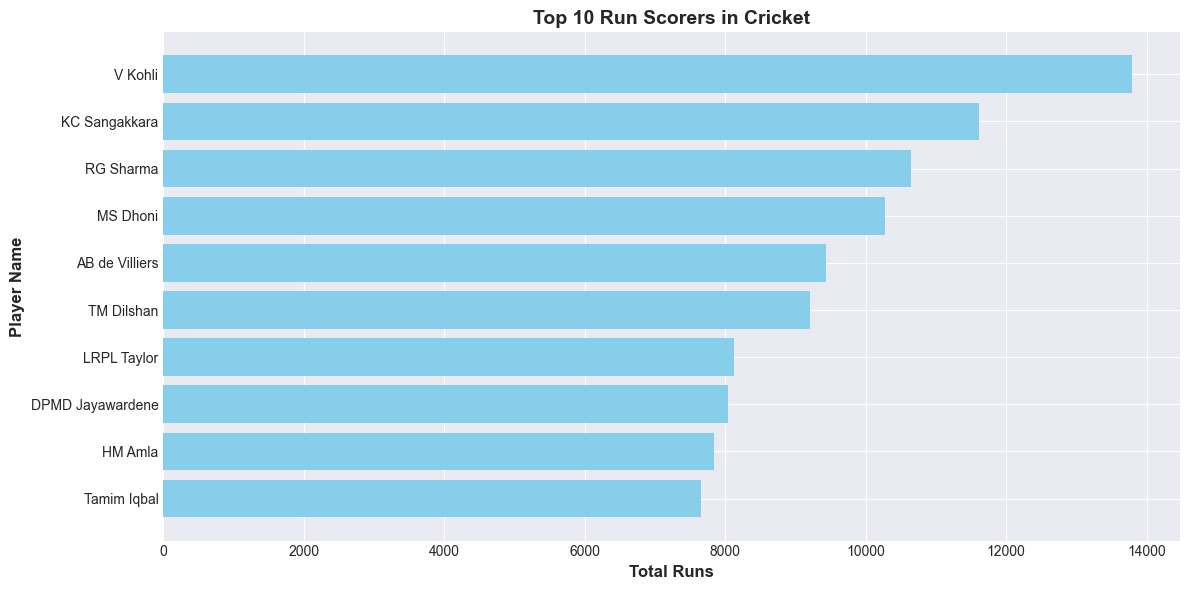

In [8]:
# Top 10 run scorers
top_run_scorers = df.nlargest(10, 'total_runs')[['player_name', 'team', 'total_runs', 'total_matches_played']]
print("=== Top 10 Run Scorers ===")
print(top_run_scorers)

# Visualization
plt.figure(figsize=(12, 6))
plt.barh(top_run_scorers['player_name'], top_run_scorers['total_runs'], color='skyblue')
plt.xlabel('Total Runs', fontsize=12, fontweight='bold')
plt.ylabel('Player Name', fontsize=12, fontweight='bold')
plt.title('Top 10 Run Scorers in Cricket', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Question 2: Which teams have the highest win percentage?
**Business Impact:** Understanding team performance for investment decisions and league partnerships

=== Top 10 Teams by Win Percentage ===
            team  matches_won  matches_lost  total_matches_played  \
20      Thailand           98            12                   110   
0      Australia        33312         14209                 47521   
6          India        35019         21892                 56911   
18  South Africa        23717         14845                 38562   
4        England        29021         21600                 50621   
17      Scotland         3034          2591                  5625   
14          Oman          462           395                   857   
13   New Zealand        18139         16812                 34951   
11         Nepal          787           783                  1570   
15      Pakistan        21863         22958                 44821   

    win_percentage  
20           89.09  
0            70.10  
6            61.53  
18           61.50  
4            57.33  
17           53.94  
14           53.91  
13           51.90  
11          

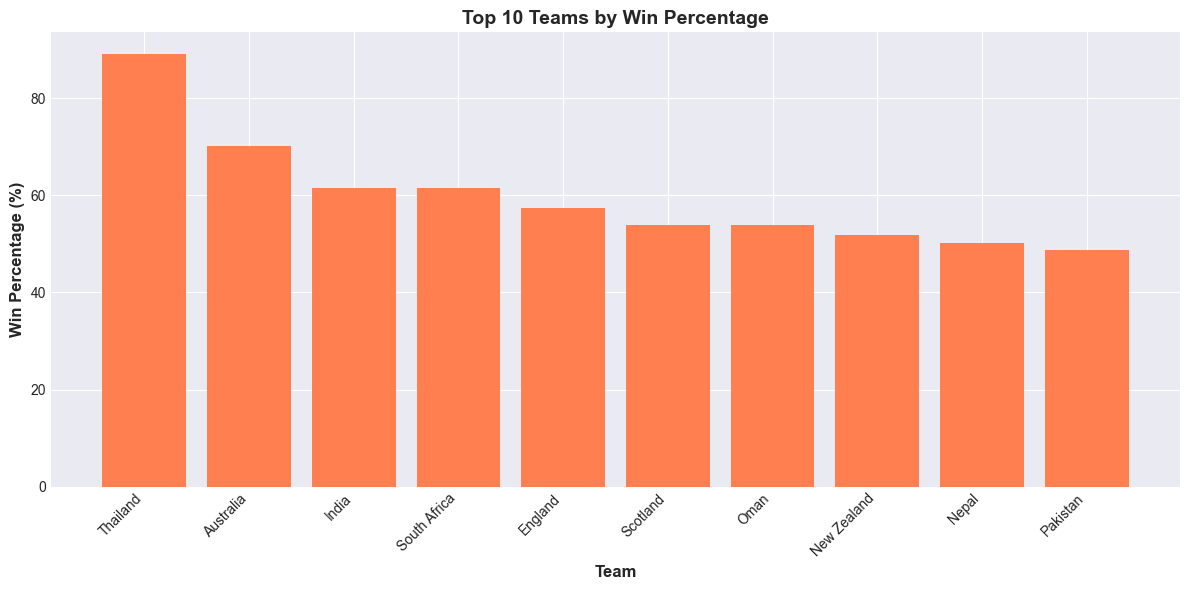

In [9]:
# Calculate team-wise performance
team_performance = df.groupby('team').agg({
    'matches_won': 'sum',
    'matches_lost': 'sum',
    'total_matches_played': 'sum'
}).reset_index()

team_performance['win_percentage'] = (team_performance['matches_won'] / 
                                       team_performance['total_matches_played'] * 100).round(2)

team_performance = team_performance.sort_values('win_percentage', ascending=False).head(10)
print("=== Top 10 Teams by Win Percentage ===")
print(team_performance)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(team_performance['team'], team_performance['win_percentage'], color='coral')
plt.xlabel('Team', fontsize=12, fontweight='bold')
plt.ylabel('Win Percentage (%)', fontsize=12, fontweight='bold')
plt.title('Top 10 Teams by Win Percentage', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Question 3: What is the distribution of player roles?
**Business Impact:** Resource allocation and team composition strategies

=== Player Role Distribution ===
role
Batter    1540
Name: count, dtype: int64


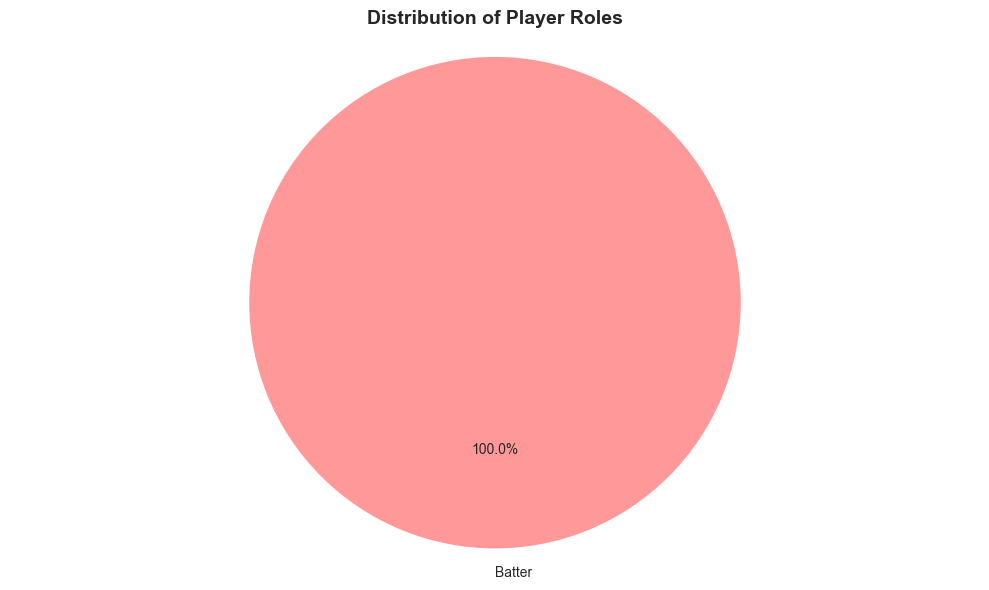

In [10]:
# Role distribution
role_distribution = df['role'].value_counts()
print("=== Player Role Distribution ===")
print(role_distribution)

# Visualization
plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
plt.pie(role_distribution.values, labels=role_distribution.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, explode=[0.05]*len(role_distribution))
plt.title('Distribution of Player Roles', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Question 4: Who are the top wicket-takers?
**Business Impact:** Identifying bowling talent for team building and endorsements

=== Top 10 Wicket Takers ===
          player_name          team  total_wickets_taken  total_overs_bowled
419        SL Malinga     Sri Lanka                  343               10803
271        MG Johnson     Australia                  243                7537
212  Mashrafe Mortaza    Bangladesh                  227                8756
482          DW Steyn  South Africa                  212                6388
89           DJ Bravo   West Indies                  193                6052
718       Imran Tahir  South Africa                  180                5556
656     Kuldeep Yadav         India                  173                5236
690        NW Bracken     Australia                  168                5095
337          R Ashwin         India                  166                6358
29          SR Watson     Australia                  162                5690


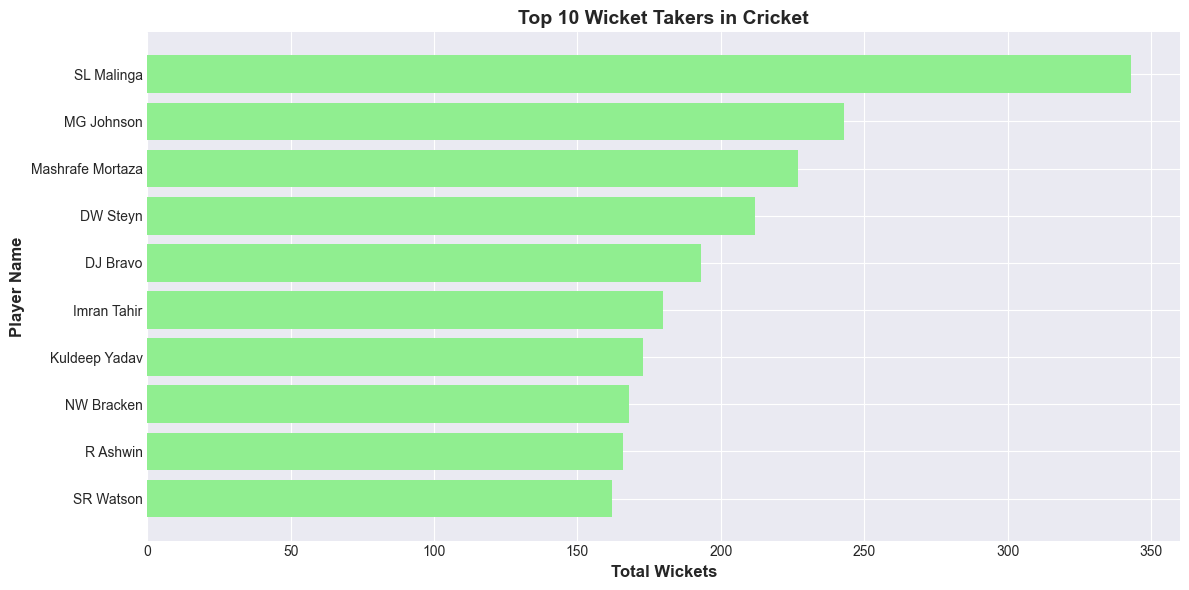

In [11]:
# Top 10 wicket takers
top_wicket_takers = df.nlargest(10, 'total_wickets_taken')[['player_name', 'team', 'total_wickets_taken', 'total_overs_bowled']]
print("=== Top 10 Wicket Takers ===")
print(top_wicket_takers)

# Visualization
plt.figure(figsize=(12, 6))
plt.barh(top_wicket_takers['player_name'], top_wicket_takers['total_wickets_taken'], color='lightgreen')
plt.xlabel('Total Wickets', fontsize=12, fontweight='bold')
plt.ylabel('Player Name', fontsize=12, fontweight='bold')
plt.title('Top 10 Wicket Takers in Cricket', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Question 5: Which players have the most Player of Match awards?
**Business Impact:** Identifying clutch performers for brand ambassadorships and premium contracts

=== Top 15 Players by Match Awards ===
        player_name          team  player_of_match_awards  \
0           V Kohli         India                      41   
1     KC Sangakkara     Sri Lanka                      26   
4    AB de Villiers  South Africa                      26   
5        TM Dilshan     Sri Lanka                      24   
2         RG Sharma         India                      23   
10       MJ Guptill   New Zealand                      22   
3          MS Dhoni         India                      20   
15     Yuvraj Singh         India                      20   
17        Q de Kock  South Africa                      19   
22  Mohammad Hafeez      Pakistan                      19   
13       RT Ponting     Australia                      17   
6       LRPL Taylor   New Zealand                      16   
8           HM Amla  South Africa                      16   
18        DA Warner     Australia                      16   
21     SR Tendulkar         India             

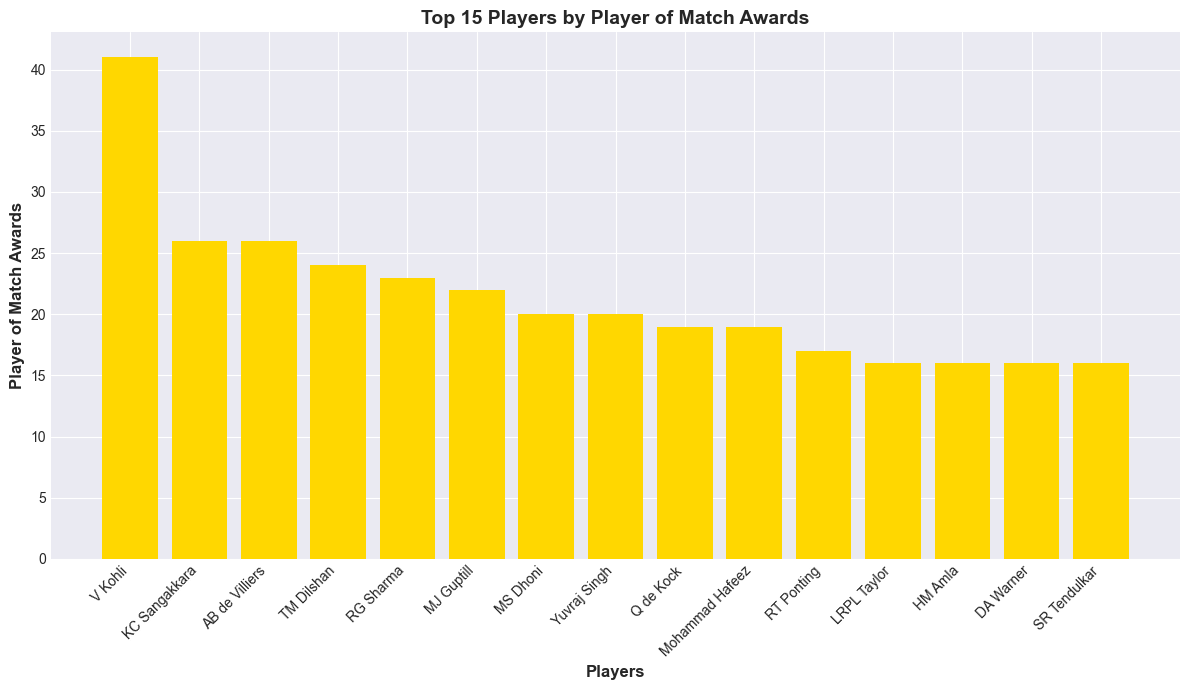

In [12]:
# Top players by awards
top_award_winners = df[df['player_of_match_awards'] > 0].nlargest(15, 'player_of_match_awards')[['player_name', 'team', 'player_of_match_awards', 'total_matches_played']]
print("=== Top 15 Players by Match Awards ===")
print(top_award_winners)

# Visualization
plt.figure(figsize=(12, 7))
plt.bar(range(len(top_award_winners)), top_award_winners['player_of_match_awards'], color='gold')
plt.xlabel('Players', fontsize=12, fontweight='bold')
plt.ylabel('Player of Match Awards', fontsize=12, fontweight='bold')
plt.title('Top 15 Players by Player of Match Awards', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_award_winners)), top_award_winners['player_name'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Question 6: What is the relationship between matches played and total runs?
**Business Impact:** Understanding player longevity and consistency for long-term contracts

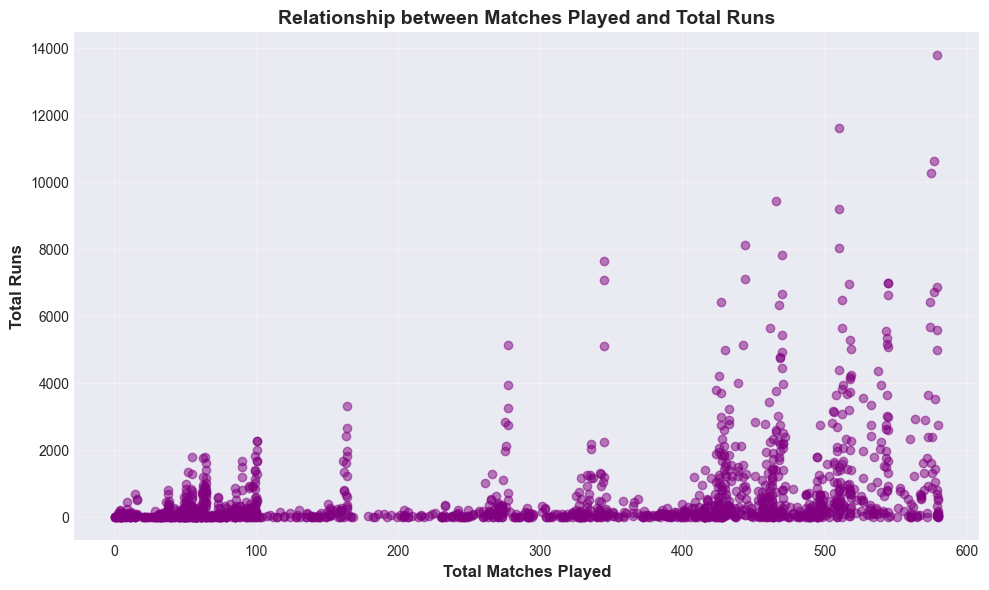


Correlation coefficient: 0.332


In [13]:
# Correlation analysis
plt.figure(figsize=(10, 6))
plt.scatter(df['total_matches_played'], df['total_runs'], alpha=0.5, c='purple')
plt.xlabel('Total Matches Played', fontsize=12, fontweight='bold')
plt.ylabel('Total Runs', fontsize=12, fontweight='bold')
plt.title('Relationship between Matches Played and Total Runs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['total_matches_played'].corr(df['total_runs'])
print(f"\nCorrelation coefficient: {correlation:.3f}")

## Question 7: Which teams have the most players in the dataset?
**Business Impact:** Understanding talent pool distribution across teams

=== Top 15 Teams by Number of Players ===
team
India                   119
West Indies             117
Sri Lanka               113
Pakistan                109
England                 107
Australia                97
South Africa             92
New Zealand              90
Bangladesh               83
Zimbabwe                 80
Scotland                 66
Netherlands              65
Ireland                  64
Canada                   60
United Arab Emirates     48
Name: count, dtype: int64


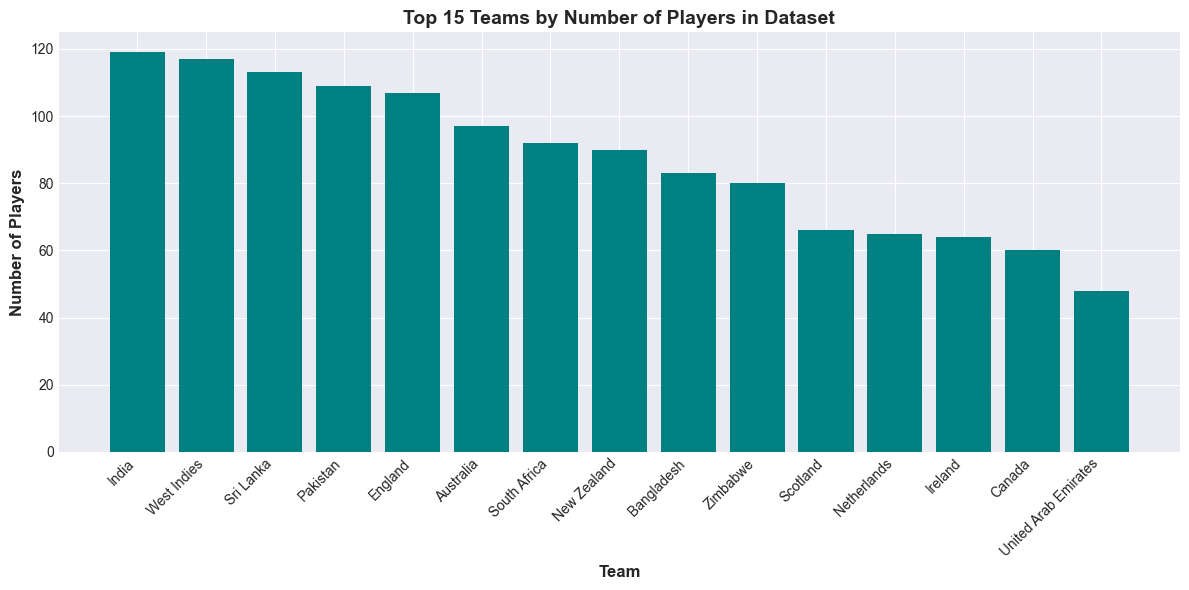

In [14]:
# Players per team
players_per_team = df['team'].value_counts().head(15)
print("=== Top 15 Teams by Number of Players ===")
print(players_per_team)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(players_per_team.index, players_per_team.values, color='teal')
plt.xlabel('Team', fontsize=12, fontweight='bold')
plt.ylabel('Number of Players', fontsize=12, fontweight='bold')
plt.title('Top 15 Teams by Number of Players in Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Question 8: What is the average performance by role?
**Business Impact:** Role-specific recruitment and salary benchmarking

=== Average Performance by Role ===
        total_runs  total_wickets_taken  total_matches_played  \
role                                                            
Batter      632.38                10.92                 289.5   

        player_of_match_awards  
role                            
Batter                    1.23  


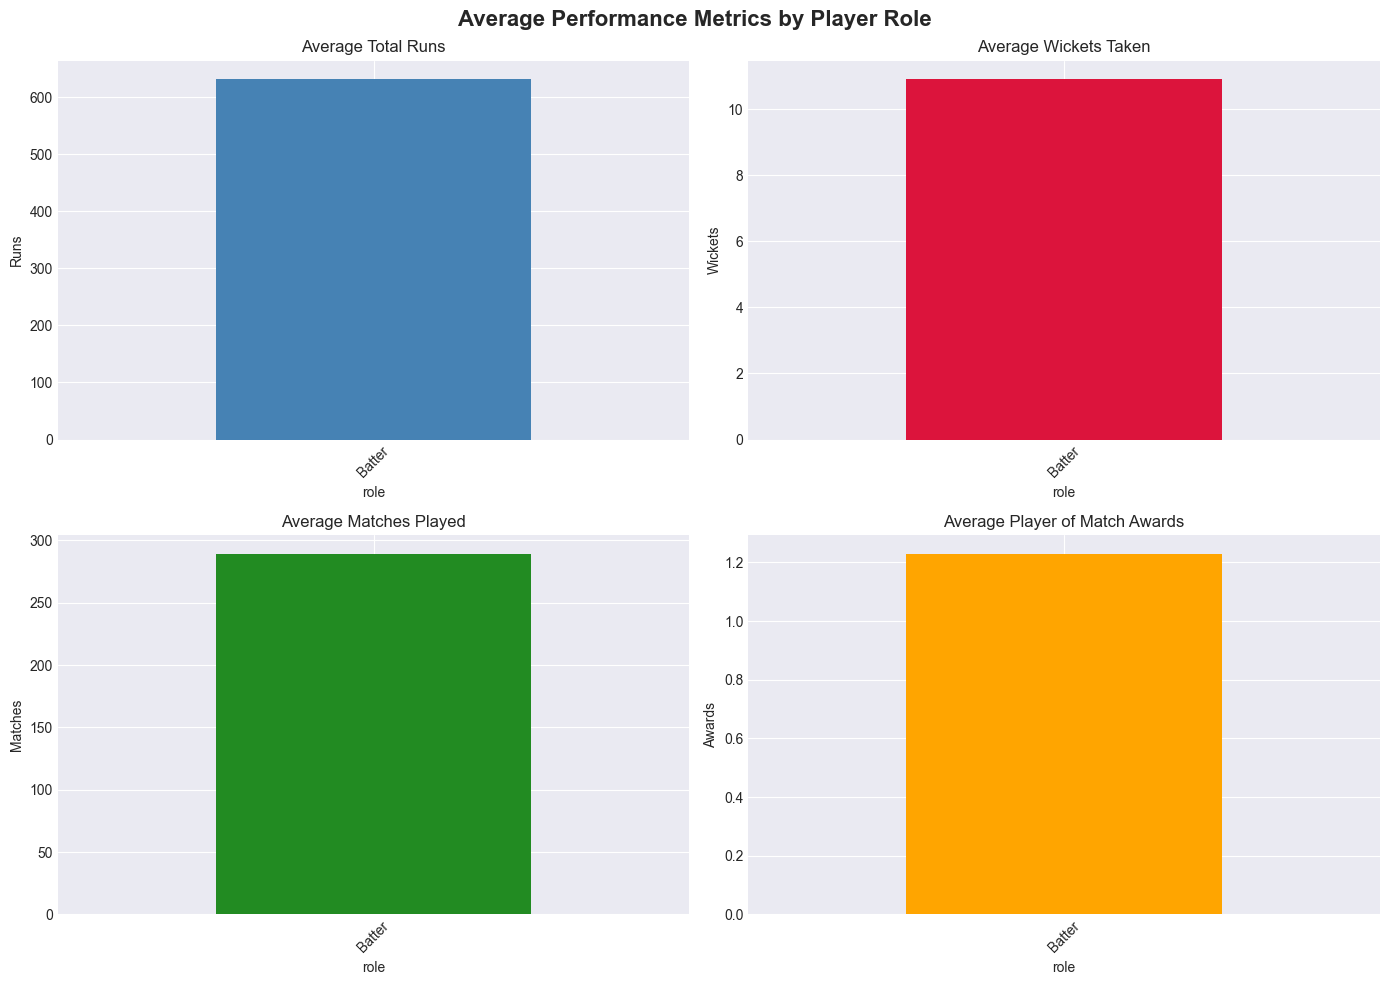

In [15]:
# Performance metrics by role
role_performance = df.groupby('role').agg({
    'total_runs': 'mean',
    'total_wickets_taken': 'mean',
    'total_matches_played': 'mean',
    'player_of_match_awards': 'mean'
}).round(2)

print("=== Average Performance by Role ===")
print(role_performance)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Average Performance Metrics by Player Role', fontsize=16, fontweight='bold')

# Total Runs
role_performance['total_runs'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Average Total Runs')
axes[0, 0].set_ylabel('Runs')
axes[0, 0].tick_params(axis='x', rotation=45)

# Total Wickets
role_performance['total_wickets_taken'].plot(kind='bar', ax=axes[0, 1], color='crimson')
axes[0, 1].set_title('Average Wickets Taken')
axes[0, 1].set_ylabel('Wickets')
axes[0, 1].tick_params(axis='x', rotation=45)

# Matches Played
role_performance['total_matches_played'].plot(kind='bar', ax=axes[1, 0], color='forestgreen')
axes[1, 0].set_title('Average Matches Played')
axes[1, 0].set_ylabel('Matches')
axes[1, 0].tick_params(axis='x', rotation=45)

# Player of Match Awards
role_performance['player_of_match_awards'].plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Average Player of Match Awards')
axes[1, 1].set_ylabel('Awards')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Question 9: Who are the most economical bowlers (best bowling average)?
**Business Impact:** Identifying value-for-money bowling talent

=== Top 10 Most Economical Bowlers (Min 20 wickets) ===
      player_name          team  total_wickets_taken  bowling_average
748  IJR Zwilling   Netherlands                   29            14.31
987    S Molineux     Australia                   23            14.74
492       J Nkomo      Zimbabwe                   25            17.24
404   JL Jonassen     Australia                  136            17.46
557    S Dhaniram        Canada                   23            17.74
448  S Lamichhane         Nepal                  120            18.21
911       GT Main      Scotland                   33            18.45
283   BJ McMullen      Scotland                   39            18.56
738   LM Kasperek   New Zealand                   57            19.14
569      S Ismail  South Africa                  142            19.87


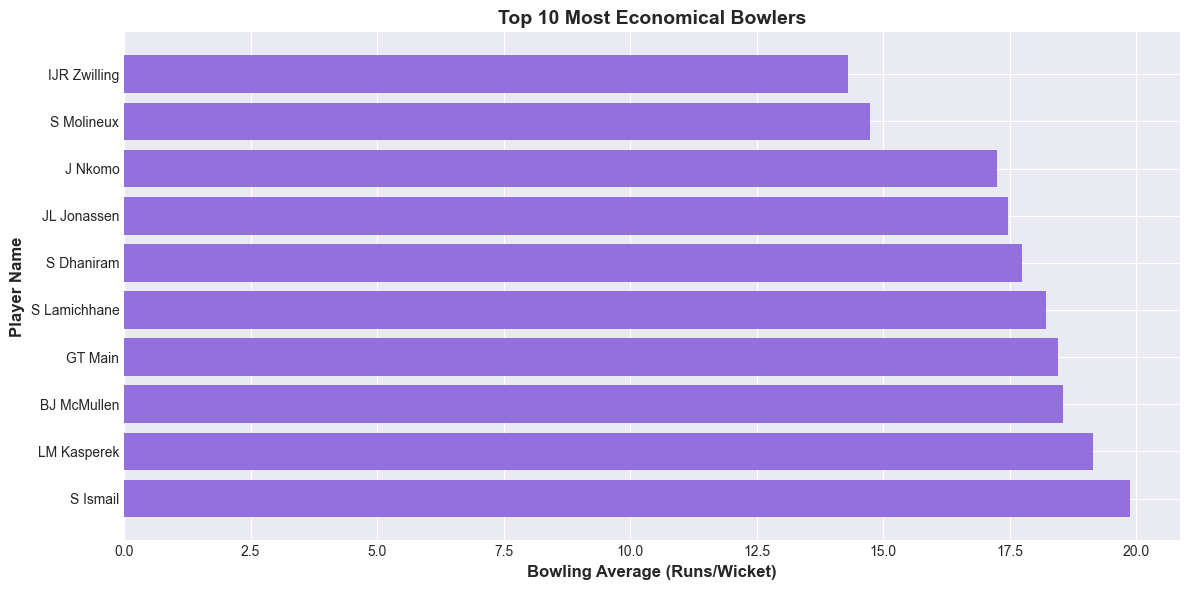

In [16]:
# Calculate bowling economy (runs per wicket for bowlers with wickets)
bowlers = df[df['total_wickets_taken'] > 20].copy()
bowlers['bowling_average'] = (bowlers['total_runs_conceded'] / bowlers['total_wickets_taken']).round(2)
best_bowlers = bowlers.nsmallest(10, 'bowling_average')[['player_name', 'team', 'total_wickets_taken', 'bowling_average']]

print("=== Top 10 Most Economical Bowlers (Min 20 wickets) ===")
print(best_bowlers)

# Visualization
plt.figure(figsize=(12, 6))
plt.barh(best_bowlers['player_name'], best_bowlers['bowling_average'], color='mediumpurple')
plt.xlabel('Bowling Average (Runs/Wicket)', fontsize=12, fontweight='bold')
plt.ylabel('Player Name', fontsize=12, fontweight='bold')
plt.title('Top 10 Most Economical Bowlers', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Question 10: What is the win-loss ratio for top performing teams?
**Business Impact:** Strategic insights for franchise investments and betting markets

=== Top 10 Teams by Win-Loss Ratio ===
            team  matches_won  matches_lost  win_loss_ratio
20      Thailand           98            12            7.54
0      Australia        33312         14209            2.34
6          India        35019         21892            1.60
18  South Africa        23717         14845            1.60
4        England        29021         21600            1.34
17      Scotland         3034          2591            1.17
14          Oman          462           395            1.17
13   New Zealand        18139         16812            1.08
11         Nepal          787           783            1.00
15      Pakistan        21863         22958            0.95


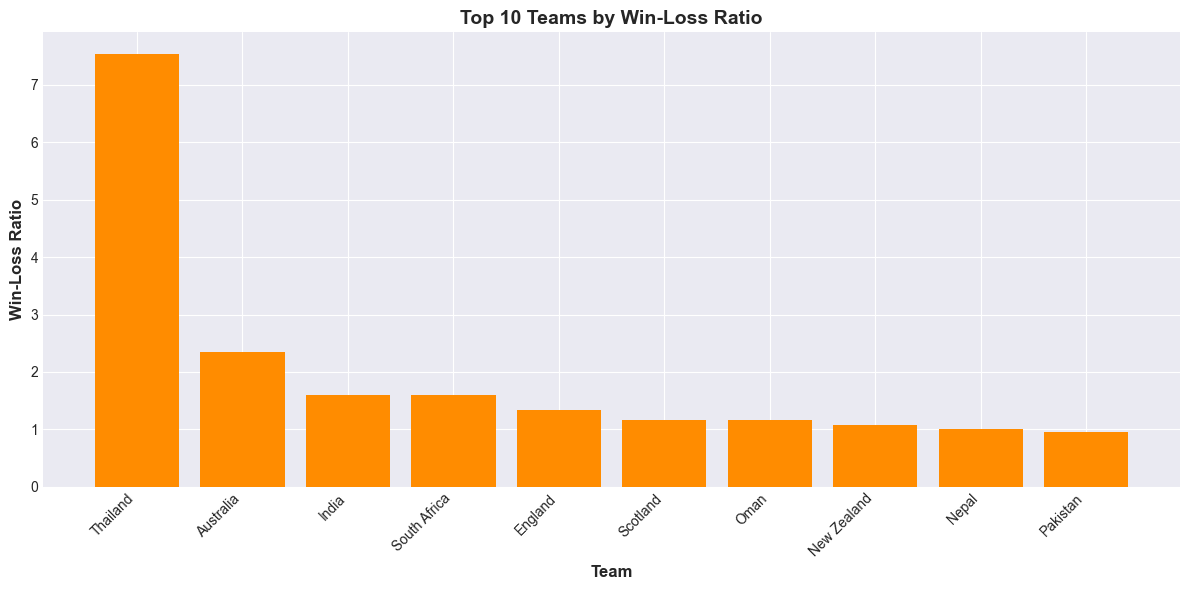

In [17]:
# Win-loss analysis
team_winloss = df.groupby('team').agg({
    'matches_won': 'sum',
    'matches_lost': 'sum'
}).reset_index()

team_winloss['win_loss_ratio'] = (team_winloss['matches_won'] / 
                                   (team_winloss['matches_lost'] + 1)).round(2)  # +1 to avoid division by zero
team_winloss = team_winloss.sort_values('win_loss_ratio', ascending=False).head(10)

print("=== Top 10 Teams by Win-Loss Ratio ===")
print(team_winloss)

# Visualization
plt.figure(figsize=(12, 6))
plt.bar(team_winloss['team'], team_winloss['win_loss_ratio'], color='darkorange')
plt.xlabel('Team', fontsize=12, fontweight='bold')
plt.ylabel('Win-Loss Ratio', fontsize=12, fontweight='bold')
plt.title('Top 10 Teams by Win-Loss Ratio', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Question 11: How many players have both batting and bowling capabilities?
**Business Impact:** Identifying all-rounders for versatile team composition

Total All-rounders (>500 runs & >20 wickets): 10

=== Top 10 All-rounders by Combined Score ===
         player_name         team  total_runs  total_wickets_taken  \
5         TM Dilshan    Sri Lanka        9212                   97   
22   Mohammad Hafeez     Pakistan        6351                  142   
15      Yuvraj Singh        India        6868                   99   
20          CH Gayle  West Indies        6433                  112   
29         SR Watson    Australia        5357                  162   
25        AD Mathews    Sri Lanka        5646                  137   
12         MJ Clarke    Australia        6988                   56   
419       SL Malinga    Sri Lanka         508                  343   
21      SR Tendulkar        India        6432                   31   
23          V Sehwag        India        5692                   58   

     all_rounder_score  
5                11152  
22                9191  
15                8848  
20                8673  
29      

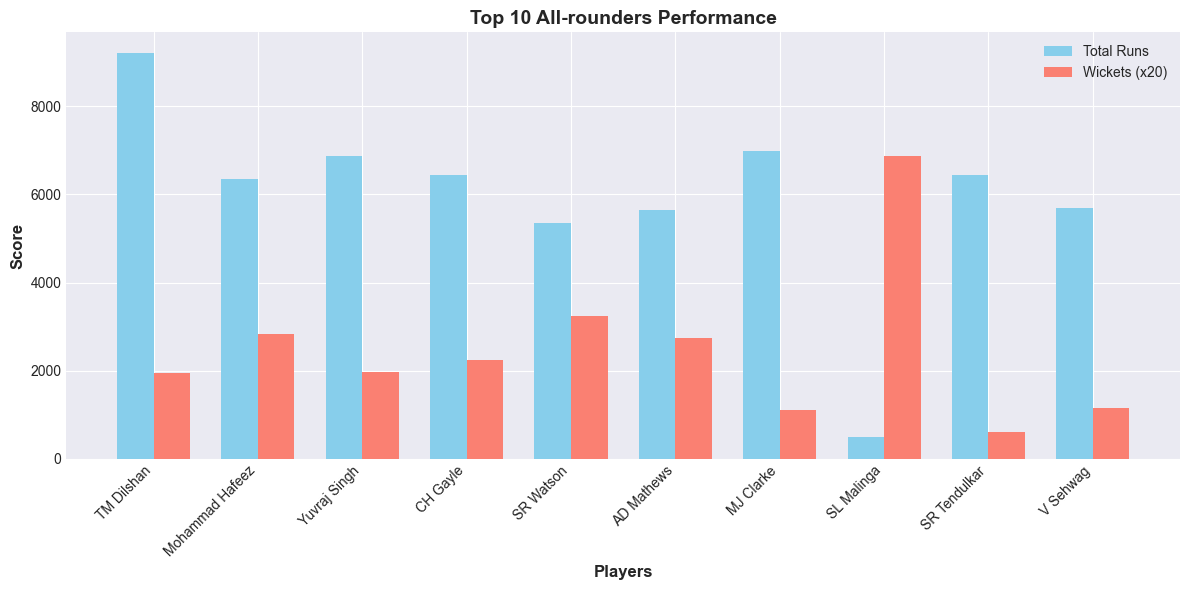

In [18]:
# All-rounders analysis (players with both runs and wickets)
all_rounders = df[(df['total_runs'] > 500) & (df['total_wickets_taken'] > 20)].copy()
all_rounders['all_rounder_score'] = (all_rounders['total_runs'] + 
                                      all_rounders['total_wickets_taken'] * 20).round(2)
all_rounders = all_rounders.nlargest(10, 'all_rounder_score')[['player_name', 'team', 'total_runs', 'total_wickets_taken', 'all_rounder_score']]

print(f"Total All-rounders (>500 runs & >20 wickets): {len(all_rounders)}")
print("\n=== Top 10 All-rounders by Combined Score ===")
print(all_rounders)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(all_rounders))
width = 0.35

ax.bar(x - width/2, all_rounders['total_runs'], width, label='Total Runs', color='skyblue')
ax.bar(x + width/2, all_rounders['total_wickets_taken']*20, width, label='Wickets (x20)', color='salmon')

ax.set_xlabel('Players', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 All-rounders Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_rounders['player_name'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Question 12: What is the distribution of matches played by players?
**Business Impact:** Understanding player experience levels for team balance

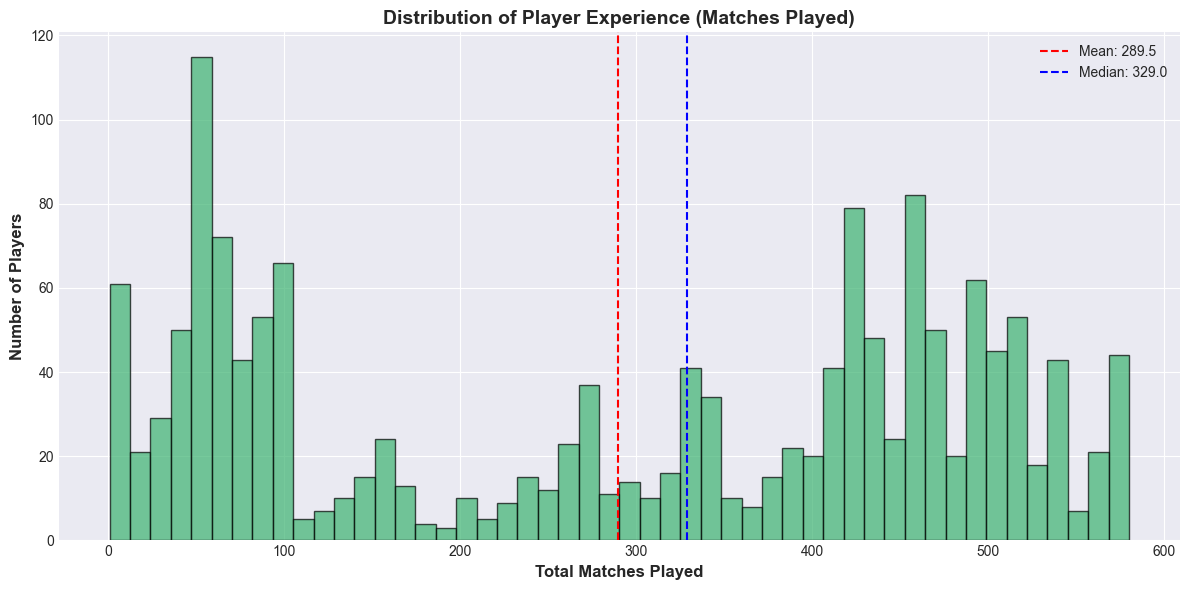


Mean matches played: 289.50
Median matches played: 329.00
Standard deviation: 190.90


In [19]:
# Experience distribution
plt.figure(figsize=(12, 6))
plt.hist(df['total_matches_played'], bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.xlabel('Total Matches Played', fontsize=12, fontweight='bold')
plt.ylabel('Number of Players', fontsize=12, fontweight='bold')
plt.title('Distribution of Player Experience (Matches Played)', fontsize=14, fontweight='bold')
plt.axvline(df['total_matches_played'].mean(), color='red', linestyle='--', label=f"Mean: {df['total_matches_played'].mean():.1f}")
plt.axvline(df['total_matches_played'].median(), color='blue', linestyle='--', label=f"Median: {df['total_matches_played'].median():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMean matches played: {df['total_matches_played'].mean():.2f}")
print(f"Median matches played: {df['total_matches_played'].median():.2f}")
print(f"Standard deviation: {df['total_matches_played'].std():.2f}")

## Question 13: Which team has the best collective batting performance?
**Business Impact:** Identifying strongest batting lineups for strategic planning

=== Top 10 Teams by Total Runs Scored ===
            team  total_runs  total_balls  num_players  runs_per_player
6          India      123473       146356          119          1037.59
0      Australia      115980       136504           97          1195.67
19     Sri Lanka       97634       127416          113           864.02
4        England       93969       112955          107           878.21
18  South Africa       87560       105009           92           951.74
15      Pakistan       82673       110265          109           758.47
23   West Indies       79325       105840          117           677.99
13   New Zealand       68366        84864           90           759.62
1     Bangladesh       49205        68738           83           592.83
24      Zimbabwe       37423        54971           80           467.79


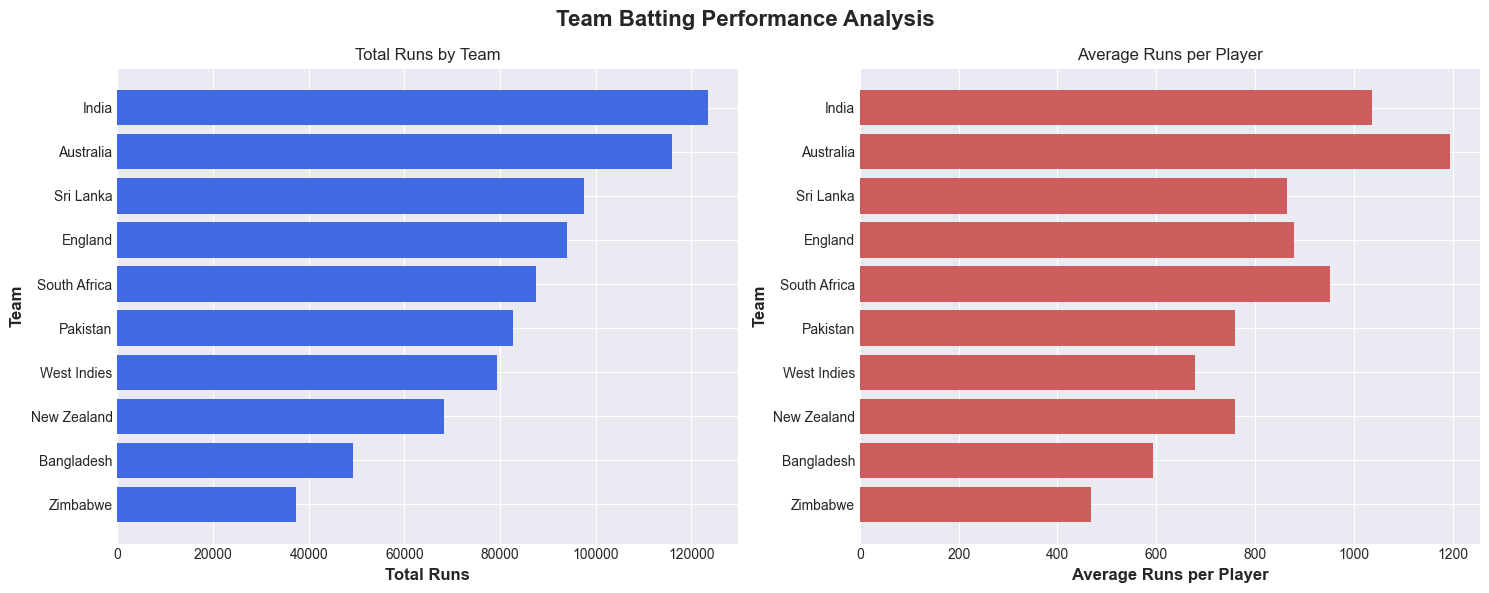

In [20]:
# Team batting strength
team_batting = df.groupby('team').agg({
    'total_runs': 'sum',
    'total_balls_faced': 'sum',
    'player_name': 'count'
}).reset_index()
team_batting.columns = ['team', 'total_runs', 'total_balls', 'num_players']
team_batting['runs_per_player'] = (team_batting['total_runs'] / team_batting['num_players']).round(2)
team_batting = team_batting.sort_values('total_runs', ascending=False).head(10)

print("=== Top 10 Teams by Total Runs Scored ===")
print(team_batting)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Team Batting Performance Analysis', fontsize=16, fontweight='bold')

# Total runs
axes[0].barh(team_batting['team'], team_batting['total_runs'], color='royalblue')
axes[0].set_xlabel('Total Runs', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Team', fontsize=12, fontweight='bold')
axes[0].set_title('Total Runs by Team')
axes[0].invert_yaxis()

# Runs per player
axes[1].barh(team_batting['team'], team_batting['runs_per_player'], color='indianred')
axes[1].set_xlabel('Average Runs per Player', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Team', fontsize=12, fontweight='bold')
axes[1].set_title('Average Runs per Player')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Question 14: What is the correlation between different performance metrics?
**Business Impact:** Understanding key performance indicators for player evaluation

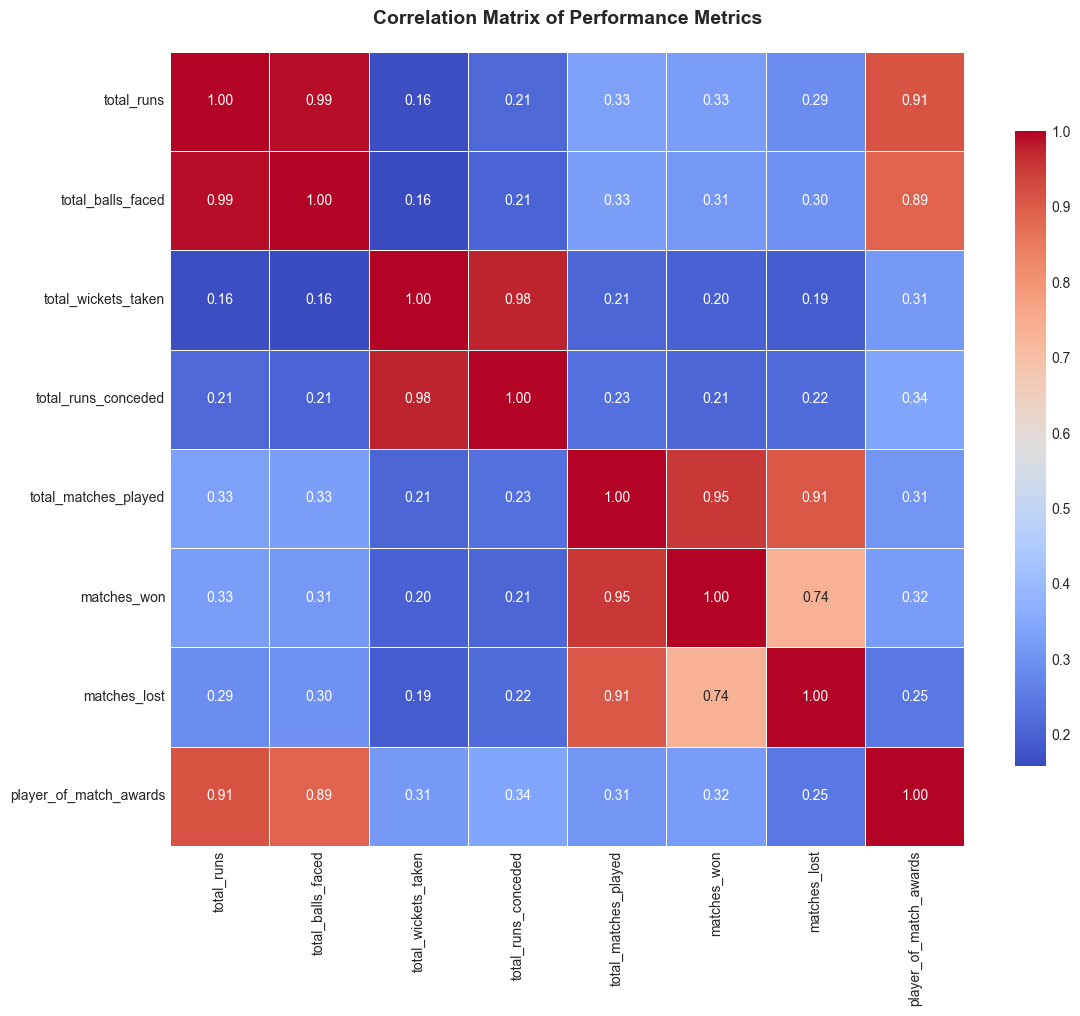

=== Strongest Correlations ===
total_runs              total_balls_faced         0.991749
total_balls_faced       total_runs                0.991749
total_wickets_taken     total_runs_conceded       0.975256
total_runs_conceded     total_wickets_taken       0.975256
total_matches_played    matches_won               0.952247
matches_won             total_matches_played      0.952247
total_runs              player_of_match_awards    0.914135
player_of_match_awards  total_runs                0.914135
total_matches_played    matches_lost              0.907009
matches_lost            total_matches_played      0.907009
dtype: float64


In [21]:
# Correlation matrix
numeric_cols = ['total_runs', 'total_balls_faced', 'total_wickets_taken', 
                'total_runs_conceded', 'total_matches_played', 'matches_won', 
                'matches_lost', 'player_of_match_awards']

correlation_matrix = df[numeric_cols].corr()

# Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Performance Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("=== Strongest Correlations ===")
# Get top correlations (excluding diagonal)
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
print(corr_pairs.sort_values(ascending=False).head(10))

## Question 15: Who are the most consistent performers (high runs and low variability)?
**Business Impact:** Identifying reliable players for crucial matches and consistent ROI

=== Top 15 Most Consistent Performers (>100 matches, >2000 runs) ===
         player_name          team  total_runs  total_matches_played  \
0            V Kohli         India       13784                   579   
1      KC Sangakkara     Sri Lanka       11618                   510   
110    RD Berrington      Scotland        2292                   101   
112       KJ Coetzer      Scotland        2280                   101   
9        Tamim Iqbal    Bangladesh        7648                   345   
11   Mushfiqur Rahim    Bangladesh        7094                   345   
67       PR Stirling       Ireland        3338                   164   
4     AB de Villiers  South Africa        9435                   466   
131       CS MacLeod      Scotland        2015                   101   
33        BRM Taylor      Zimbabwe        5130                   277   
2          RG Sharma         India       10646                   577   
6        LRPL Taylor   New Zealand        8126                   44

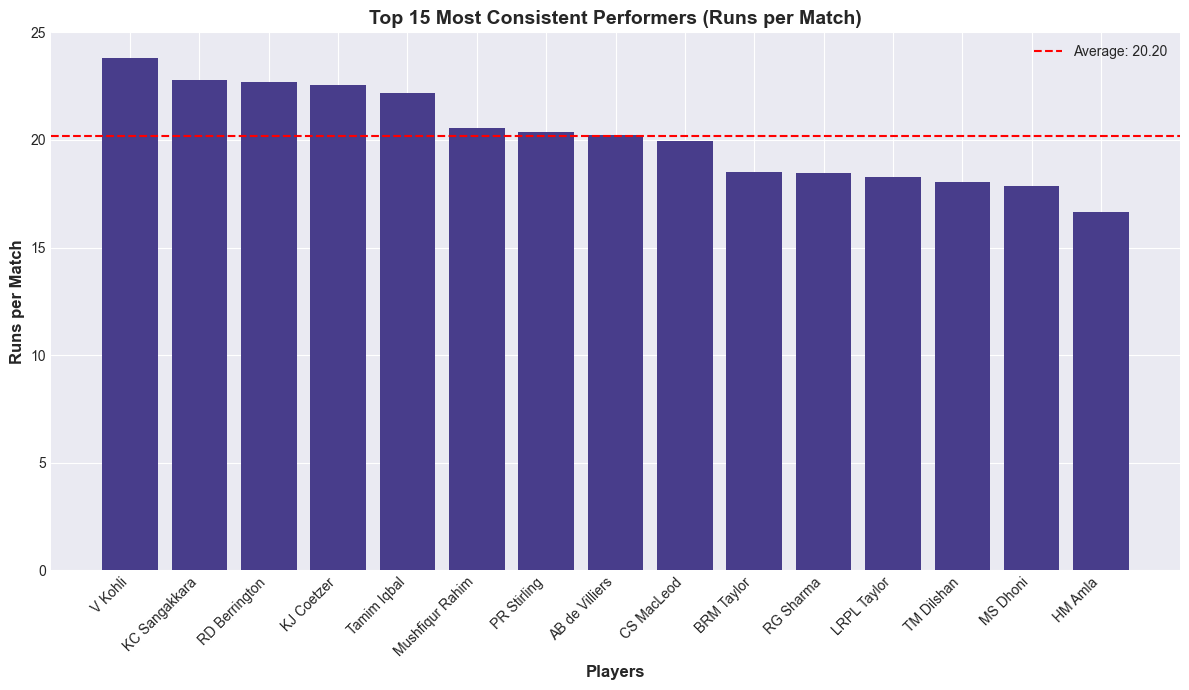

In [22]:
# Consistency analysis (players with >100 matches and >2000 runs)
consistent_players = df[(df['total_matches_played'] > 100) & (df['total_runs'] > 2000)].copy()
consistent_players['runs_per_match'] = (consistent_players['total_runs'] / 
                                         consistent_players['total_matches_played']).round(2)
consistent_players = consistent_players.nlargest(15, 'runs_per_match')[['player_name', 'team', 'total_runs', 
                                                                          'total_matches_played', 'runs_per_match']]

print("=== Top 15 Most Consistent Performers (>100 matches, >2000 runs) ===")
print(consistent_players)

# Visualization
plt.figure(figsize=(12, 7))
plt.bar(range(len(consistent_players)), consistent_players['runs_per_match'], color='darkslateblue')
plt.xlabel('Players', fontsize=12, fontweight='bold')
plt.ylabel('Runs per Match', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Consistent Performers (Runs per Match)', fontsize=14, fontweight='bold')
plt.xticks(range(len(consistent_players)), consistent_players['player_name'], rotation=45, ha='right')
plt.axhline(y=consistent_players['runs_per_match'].mean(), color='r', linestyle='--', 
            label=f'Average: {consistent_players["runs_per_match"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

---
## Summary and Key Insights
---

In [23]:
print("="*80)
print("KEY BUSINESS INSIGHTS FROM CRICKET PLAYERS EDA")
print("="*80)

print("\n1. TALENT IDENTIFICATION:")
print(f"   - Total players analyzed: {len(df)}")
print(f"   - Top run scorer: {df.nlargest(1, 'total_runs')['player_name'].values[0]}")
print(f"   - Top wicket taker: {df.nlargest(1, 'total_wickets_taken')['player_name'].values[0]}")

print("\n2. TEAM PERFORMANCE:")
team_perf = df.groupby('team')['matches_won'].sum().nlargest(1)
print(f"   - Most successful team: {team_perf.index[0]} ({team_perf.values[0]} wins)")

print("\n3. ROLE DISTRIBUTION:")
for role, count in df['role'].value_counts().items():
    print(f"   - {role}: {count} players ({count/len(df)*100:.1f}%)")

print("\n4. EXPERIENCE LEVELS:")
print(f"   - Average matches per player: {df['total_matches_played'].mean():.1f}")
print(f"   - Median matches per player: {df['total_matches_played'].median():.1f}")
print(f"   - Most experienced player: {df.nlargest(1, 'total_matches_played')['player_name'].values[0]}")

print("\n5. ALL-ROUNDER TALENT:")
all_rounders_count = len(df[(df['total_runs'] > 500) & (df['total_wickets_taken'] > 20)])
print(f"   - Players with >500 runs and >20 wickets: {all_rounders_count}")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)

KEY BUSINESS INSIGHTS FROM CRICKET PLAYERS EDA

1. TALENT IDENTIFICATION:
   - Total players analyzed: 1540
   - Top run scorer: V Kohli
   - Top wicket taker: SL Malinga

2. TEAM PERFORMANCE:
   - Most successful team: India (35019 wins)

3. ROLE DISTRIBUTION:
   - Batter: 1540 players (100.0%)

4. EXPERIENCE LEVELS:
   - Average matches per player: 289.5
   - Median matches per player: 329.0
   - Most experienced player: KL Rahul

5. ALL-ROUNDER TALENT:
   - Players with >500 runs and >20 wickets: 104

END OF ANALYSIS
